# 06 Qiskit简介与应用

## 示例

In [ ]:
import numpy as np
from qiskit import *

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer  # 从qiskit_aer导入Aer

# 创建3量子比特电路
circ = QuantumCircuit(3)
circ.h(0)          # 第0个比特加H门（Hadamard门，创建叠加态）
circ.cx(0, 1)      # 第0和1个比特加CX门（受控非门，纠缠）
circ.cx(0, 2)      # 第0和2个比特加CX门（进一步纠缠）

# 选择态矢模拟器后端
backend = Aer.get_backend('statevector_simulator')

# 执行电路（使用backend.run替代execute）
result = backend.run(circ).result()

# 获取并打印量子态矢量（保留3位小数）
output = result.get_statevector(circ, decimals=3)
print(output)


Statevector([0.707+0.j, 0.   +0.j, 0.   +0.j, 0.   +0.j, 0.   +0.j,
             0.   +0.j, 0.   +0.j, 0.707+0.j],
            dims=(2, 2, 2))


## 量子电路与量子门

Qiskit中使用QuantumCircuit(量子比特个数[，经典比特个数])来创建量子电路

In [ ]:
circ = QuantumCircuit(3)        #3个量子比特的量子电路

In [ ]:
circ_with_cbit = QuantumCircuit(3, 3)        #3个量子比特和3个经典比特的量子电路

如果我们想单独声明量子比特和经典比特，可以分别使用QuantumRegister类和ClassicalRegister类

In [ ]:
qbit = QuantumRegister(3)
cbit = ClassicalRegister(3)

In [ ]:
circ = QuantumCircuit(qbit, cbit)

同时量子电路可以通过向自己的门函数传入相应量子比特序号，从而进行量子门的添加

In [ ]:
circ.h(0)                       #给第0个比特加一个H门
circ.cx(0, 1)                   #给第0和1个比特加一个Cx门
circ.cx(0, 2)

处于可视化的目的，我们使用量子电路的draw函数进行电路绘图

In [ ]:
circ.draw()

┌───┐          
q0_0: ┤ H ├──■────■──
      └───┘┌─┴─┐  │  
q0_1: ─────┤ X ├──┼──
           └───┘┌─┴─┐
q0_2: ──────────┤ X ├
                └───┘
c0: 3/═══════════════

在Jupyter Notebook中，我们还可以向draw函数传入参数**mpl**使得作图更加美观

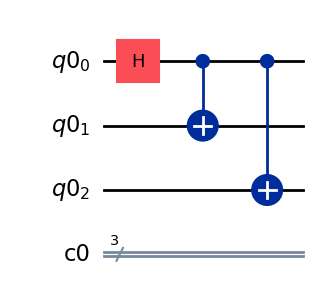

In [ ]:
circ.draw('mpl')

一般而言，电路的初始量子态均为$\left|0\right>$，当然Qiskit也支持我们使用任意长度为1的向量来初始化：

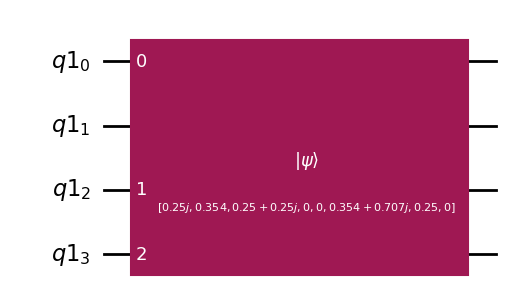

In [ ]:
import math
desired_vector = [
    1 / math.sqrt(16) * complex(0, 1),
    1 / math.sqrt(8) * complex(1, 0),
    1 / math.sqrt(16) * complex(1, 1),
    0,
    0,
    1 / math.sqrt(8) * complex(1, 2),
    1 / math.sqrt(16) * complex(1, 0),
    0]

desired_vector2 = [
    1 / math.sqrt(16) * 1j,
    1 / math.sqrt(8) * 1,
    1 / math.sqrt(16) * 1 + 1j,
    0,
    0,
    1 / math.sqrt(8) * 1 + 2j,
    1 / math.sqrt(16) * 1,
    0]
 
q = QuantumRegister(4)
 
qc = QuantumCircuit(q)

qc.initialize(desired_vector, [q[0],q[2],q[3]])

qc.draw('mpl')

其中使用到了函数initialize(目标向量，初始化位置)

注意到初始态矢量为
$$\left|\psi\right>=\frac{i}{4}\left|000\right>+\frac{1}{\sqrt{8}}\left|001\right>+\frac{1+i}{4}\left|010\right>+\frac{1+2i}{\sqrt{8}}\left|101\right>+\frac{1}{4}\left|110\right>$$

## 认识后端

所有后端都存放在qiskit.Aer库当中，我们可以使用以下语句导入该库.

In [ ]:
# 正确导入 Aer（从 qiskit_aer 包导入）
from qiskit_aer import Aer

# 示例：使用 Aer 的态矢模拟器
backend_aer = Aer.get_backend('statevector_simulator')
print("Aer 模拟器加载成功：", backend_aer)

Aer 模拟器加载成功： StatevectorSimulator('statevector_simulator')


通用的后端调用流程是：

+ 首先利用Aer.get_backend(后端名称)**获取指定后端**

+ 然后使用qiskit.run(电路，后端)**执行电路**，并将结果保存在job变量当中

+ 随后使用job.result()函数**获取执行结果**

+ 最后从中**调用相应函数**（如get_statevector(电路，参数)）获取最终结果

### 态矢后端

态矢后端对应的模拟器名称为**statevector_simulator**，用于计算在总量子态经过电路演化后得到的最终量子态

In [ ]:
backend = Aer.get_backend('statevector_simulator')  ## 获取指定后端
result  = backend.run(circ).result()                ## 获取执行结果
output  = result.get_statevector(circ, decimals=3)  ## 调用相应函数
print(output)

Statevector([0.707+0.j, 0.   +0.j, 0.   +0.j, 0.   +0.j, 0.   +0.j,
             0.   +0.j, 0.   +0.j, 0.707+0.j],
            dims=(2, 2, 2))


依上所见，态矢后端的相应函数为**get_statevector**(电路，参数)

### 酉后端

酉后端对应的模拟器名称为**unitary_simulator**，用于计算电路本身对应的矩阵。

如果将该矩阵记为
$$U=\left[\begin{matrix}u_{11} & u_{12} & \cdots \\ u_{21} & u_{22} & \cdots \\ \vdots & \vdots & \ddots\end{matrix}\right]$$
而态矢后端计算出的最终态为
$$\left|最终\right>=\left[\begin{matrix}a_1 \\ a_2 \\ \vdots\end{matrix}\right]$$
则整个电路可以写成如下的数学形式：
$$\left|最终\right>=U\left|初始\right>$$

In [ ]:
backend = Aer.get_backend('unitary_simulator')  ## 获取指定后端
result  = backend.run(circ).result()            ## 获取执行结果
output  = result.get_unitary(circ, decimals=3)  ## 调用相应函数
print(output)

Operator([[ 0.707+0.j,  0.707-0.j,  0.   +0.j,  0.   +0.j,  0.   +0.j,
            0.   +0.j,  0.   +0.j,  0.   +0.j],
          [ 0.   +0.j,  0.   +0.j,  0.   +0.j,  0.   +0.j,  0.   +0.j,
            0.   +0.j,  0.707+0.j, -0.707+0.j],
          [ 0.   +0.j,  0.   +0.j,  0.707+0.j,  0.707-0.j,  0.   +0.j,
            0.   +0.j,  0.   +0.j,  0.   +0.j],
          [ 0.   +0.j,  0.   +0.j,  0.   +0.j,  0.   +0.j,  0.707+0.j,
           -0.707+0.j,  0.   +0.j,  0.   +0.j],
          [ 0.   +0.j,  0.   +0.j,  0.   +0.j,  0.   +0.j,  0.707+0.j,
            0.707-0.j,  0.   +0.j,  0.   +0.j],
          [ 0.   +0.j,  0.   +0.j,  0.707+0.j, -0.707+0.j,  0.   +0.j,
            0.   +0.j,  0.   +0.j,  0.   +0.j],
          [ 0.   +0.j,  0.   +0.j,  0.   +0.j,  0.   +0.j,  0.   +0.j,
            0.   +0.j,  0.707+0.j,  0.707-0.j],
          [ 0.707+0.j, -0.707+0.j,  0.   +0.j,  0.   +0.j,  0.   +0.j,
            0.   +0.j,  0.   +0.j,  0.   +0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 

### OpenQASM后端

对一个量子电路，我们需要测量它来得到（理想的）实际结果，否则我们不能从量子态中得到任何信息。而测量这一行为则会导致量子比特坍缩到经典比特。我们使用量子电路的measure函数添加测量门：

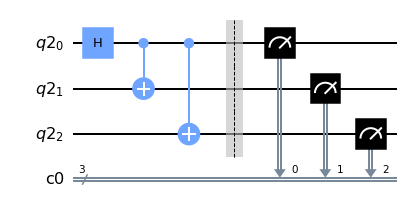

In [ ]:
# 可以接续我们的测试代码
# 再创建一个量子电路以进行测量操作
# 绘图时会生成3 qubits + 3 bits = 6个道
meas = QuantumCircuit(3, 3)
# 在第0~2个量子比特道上加一个隔板以进行区分
meas.barrier(range(3))
# 建立从量子到经典的测量映射，相当于把测量结果移至经典道
meas.measure(range(3), range(3))

qc = circ.compose(meas)                # 电路的可加性
qc.draw('mpl')

OpenQASM后端用于实打实地测量最终量子态，其对应的后端名称为**qasm_simulator**，原理是制备大量初始量子态输入电路当中，最后测量对应的最终量子态。

In [ ]:
# 导入OpenQASM后端
backend2 = Aer.get_backend('qasm_simulator')
 
# 基于OpenQASM后端运行我们的电路
# 这里用参数shots把样本数设定为1024（然而事实上是默认值）
job = execute(qc, backend2, shots=1024)
 
# 获得结果
result = job.result()
 
counts = result.get_counts(qc)
print(counts)

{'111': 521, '000': 503}


如何理解这一结果呢？我们可以通过计算一个哈达吗门和两个CNOT门作用于量子电路后得出的最终态为
$$\left|\psi\right>=\frac{1}{\sqrt{2}}(\left|000\right>+\left|111\right>)$$
如此一来，两种量子态各占约50%的结果就是符合理论的了。

## 绘图

绘图要使用qiskit.visualization库

In [ ]:
from qiskit.visualization import *

绘图的对象永远是量子态，也就是statevector。量子态可以是态矢量，也可以是态矩阵$\rho$
$$\rho = \left|\psi\right>\left<\psi\right|=\sum_k\left|\psi_k\right>\left<\psi_k\right|$$
为方便，我们先创建一个贝尔态并调用态矢后端

In [ ]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

In [ ]:
backend = Aer.get_backend('statevector_simulator')
job = execute(bell, backend)
result = job.result()
statevector = result.get_statevector(bell, decimals=3)

In [ ]:
statevector

Statevector([0.707+0.j, 0.   +0.j, 0.   +0.j, 0.707+0.j],
            dims=(2, 2))


### 直方图
plot_histogram：直方图用于绘制OpenQASM后端返回的counts

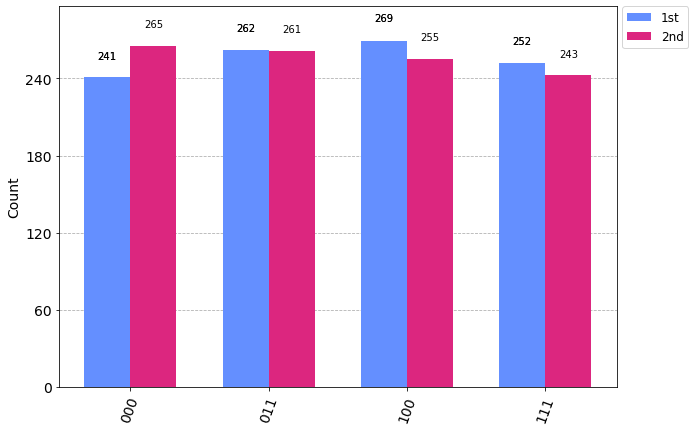

In [ ]:
circ = QuantumCircuit(3)
meas = QuantumCircuit(3, 3)
# 根据测试部分中的描述，现在第0个和第2个量子比特都处于/0>和/1>的叠加态
# 每个单态的概率皆为50%=1/2
circ.h(0)
circ.h(2)
circ.cx(0, 1)
 
meas.barrier(range(3))
meas.measure(range(3), range(3))
qc = circ.compose(meas)
 
backend = Aer.get_backend('qasm_simulator')
result1 = execute(qc, backend).result()
result2 = execute(qc, backend).result()
 
counts1 = result1.get_counts(qc)
counts2 = result2.get_counts(qc)
legends = ['1st', '2nd'] # 加入图例
plot_histogram([counts1, counts2], legend=legends, figsize=(10, 7))

### 城市图

plot_state_city: 将量子态矩阵分成实部和虚部进行绘制，会形成立体的柱状图

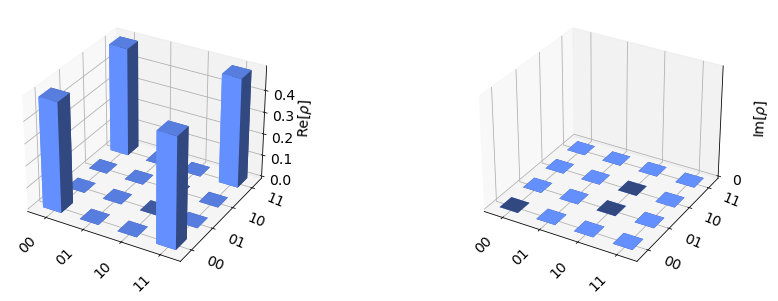

In [ ]:
plot_state_city(statevector)

### Q球图
plot_state_qsphere:Qiskit中的特色菜，将某量子态的振幅和相位绘制在球体中，并分别用线条粗细和颜色区分.对混合态则会将每个分量的qsphere绘制出来，下称“Q球图”

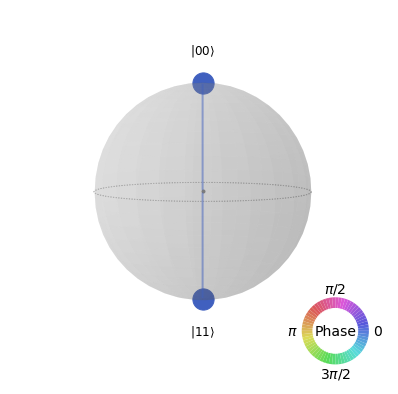

In [ ]:
plot_state_qsphere(statevector)

### Bloch球图
plot_bloch_multivector：将态向量画在布洛赫球面上

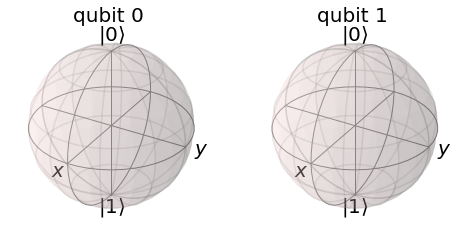

In [ ]:
plot_bloch_multivector(statevector)

### Pauli图
plot_state_paulivec：相当于用泡利矩阵展开量子态

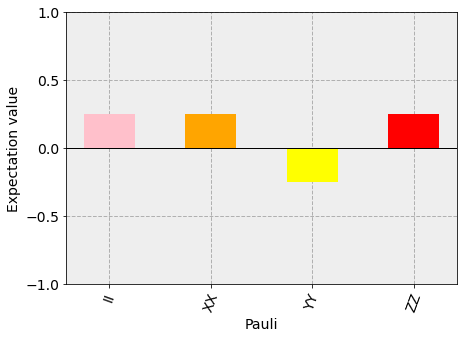

In [ ]:
plot_state_paulivec(statevector, color=['pink','orange','yellow','red'])

### Bloch矢量图
plot_bloch_vector：布洛赫矢量被定义为
$$\vec{v}=\left[\begin{matrix}Tr[X\rho]\\Tr[Y\rho]\\Tr[Z\rho]\end{matrix}\right]$$

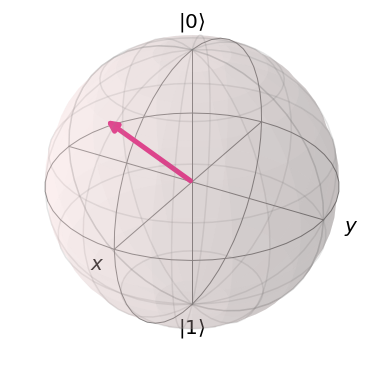

In [ ]:
plot_bloch_vector([0.77,-0.2,0.79])

## 进阶电路

### Gate类
Gate类来自于qiskit.circuit库，是一切门的基类，既可以表示通用量子门，也可以用来自定义门：

In [ ]:
from qiskit.circuit import Gate
gt1 = Gate(name="my_gate", num_qubits=2, params=[])

此处name将会在后面绘制出的电路图里显示，num_qubits就是该门需要作为参数的量子比特数

如果要把门添加到某一电路中去，使用**append**方法:

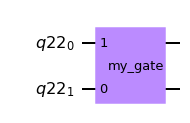

In [ ]:
from qiskit import QuantumRegister, QuantumCircuit
qr1 = QuantumRegister(2)
circ1 = QuantumCircuit(qr1)
 
circ1.append(gt1, [qr1[1], qr1[0]])
circ1.draw('mpl')

### 子电路

新建电路如下

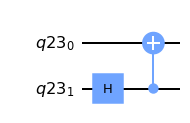

In [ ]:
qr2 = QuantumRegister(2)
sub_circ = QuantumCircuit(qr2)
 
sub_circ.h(qr2[1])
sub_circ.cx(qr2[1],qr2[0])
sub_circ.name = 'subcircuit_1'
sub_circ.draw('mpl')

使用**append**函数将某一个电路作为子电路嵌入另一个电路当中，注意嵌入的应当是子电路的insturction版本，也就是把电路变成等效的矩阵（回忆酉后端）

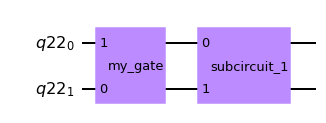

In [ ]:
circ1.append(sub_circ.to_instruction(), [qr1[0], qr1[1]])
circ1.draw('mpl')

Qiskit中量子电路还支持完全分解，即调用电路的**decompose**函数，进而可以把电路分解成通用量子门形式（注意decompose函数不会改变原来的量子电路，只是返回新的量子电路）

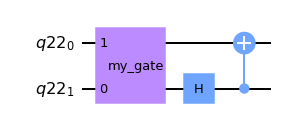

In [ ]:
circ1.decompose().draw('mpl')

### 参数化
量子门的参数化有以下两个好处：

+ 参数化电路会减少编译损耗

+ 参数化可以像普通电路那样被组合

qiskit.circuit库中的Parameter类用于实现量子门的“参数化”，让电路像一个函数一样运行：

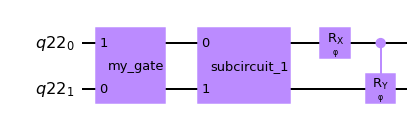

In [ ]:
from qiskit.circuit import Parameter
phi = Parameter('φ')
 
# phi就像正常角度一样传入即可
circ1.rx(phi, qr1[0])
circ1.cry(phi,qr1[0], qr1[1])

circ1.draw('mpl')

需要传入参数时应当使用电路的bind_parameters函数。和decompose函数一样，它不会改变原先的电路，只会返回新的电路：

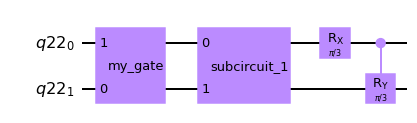

In [ ]:
circ1.bind_parameters({phi: np.pi / 3}).draw('mpl')

### 操作子
qiskit.quantum_info.operators库中的Operator类允许我们从矩阵直接创建一种门（不一定是酉矩阵）

每一个Operator实例都包含两个基本属性 ：

+ data：numpy array, 储存操作子的矩阵表示

+ dim：操作子的维数信息，不一定和data中的矩阵相同

操作子维数分为input_dims和output_dims，分别对应的是操作子要施加的量子态维数和生成的量子态维数

In [ ]:
from qiskit.quantum_info.operators import Operator
import numpy as np
 
op = Operator(np.random.rand(2 ** 1, 2 ** 2))
print(op.data)                       # 会输出随机生成的矩阵 
print(op.dim)                        # 输出(4, 2)
print(op.input_dims())               # 输出(2, 2)
print(op.output_dims())              # 输出(2,)

[[0.05528599+0.j 0.55661145+0.j 0.70193397+0.j 0.48402779+0.j]
 [0.8814885 +0.j 0.42745936+0.j 0.58045102+0.j 0.81378841+0.j]]
(4, 2)
(2, 2)
(2,)


Operator也可以通过Pauli、Gate、Instruction甚至是QuantumCircuit来创建

In [ ]:
from qiskit.circuit.library import HGate
 
opH = Operator(HGate())
opH

Operator([[ 0.70710678+0.j,  0.70710678+0.j],
          [ 0.70710678+0.j, -0.70710678+0.j]],
         input_dims=(2,), output_dims=(2,))

Operator之间还可以进行组合，也就是我们所说的乘积

乘积依旧分成两种形式：张量积和矩阵乘法

#### 张量积

张量积对应的两个函数（假设Op1和Op2都是单量子门）：

+ op1.tensor(op2) 等价于$Op1\otimes Op2$，其结果还可以表示成一个矩阵，但是在实际作用时，则是Op2对应qubit_0, Op1对应qubit_1

+ op1.expand(op2) 等价于$Op2\otimes Op1$ 

$$(Op1 \otimes Op2)\left|ab\right>$$

普通的矩阵乘法则需要调用compose()方法，但和张量积相同，它也在顺序上存在两种形式（矩阵乘法对两矩阵有一定的维数要求）

+ op1.compose(op2)等价于op2·op1

+ op1.compose(op2, front=True)等价于op1.op2

#### 子系统乘法

子系统乘法会将大的矩阵作张量分解，将其拆成若干小矩阵，而我们的目的则是选出那些我们想要作用的小矩阵，结果会自动执行张量积并变回大矩阵
$$(I\otimes X \otimes I)\left|abc\right>$$
$$(X\otimes I \otimes Z)$$

In [ ]:
from qiskit.quantum_info.operators import Pauli
op = Operator(np.eye(2 ** 3))
XZ = Operator(Pauli('XZ'))
op.compose(XZ, qargs=[0, 2])

Operator([[ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
           -1.+0.j],
          [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))